In [341]:
import numpy as np
import matplotlib.pyplot as plt

In [342]:
SIZE = 32
M = 5

In [343]:
def show_img(ax, flat_vec):
    ax.imshow(flat_vec.reshape(SIZE, SIZE), cmap='plasma', vmin=-1, vmax=1)
    ax.axis('off')

In [344]:
import art

arts, names = art.create_arts()

selected_arts = arts[:M]

names = [name for _, name in selected_arts]
selected_arts = [art for art, _ in selected_arts]

In [345]:
def plot_selected_arts(selected_arts, names=None):
  n = len(selected_arts)
  cols = min(n, 5)
  rows = (n + cols - 1) // cols
  fig, axs = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
  fig.suptitle("Selected Memories to train hopfield network", fontsize=16)
  for i in range(rows * cols):
      ax = axs.flat[i] if n > 1 else axs
      if i < n:
          show_img(ax, selected_arts[i])
          ax.set_title(f"{names[i] if names else f"Memory {i + 1}"}")
      else:
          ax.axis('off')
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

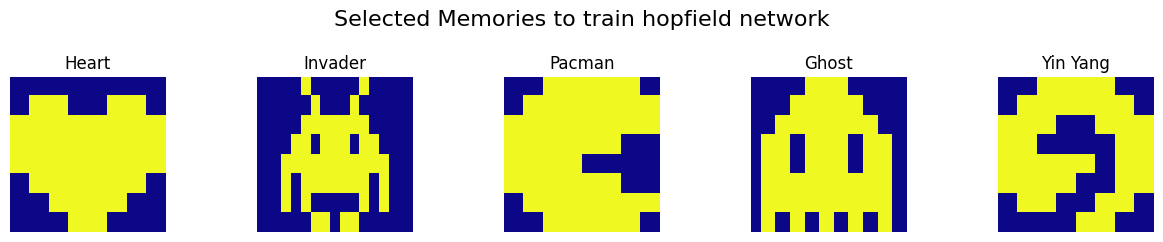

In [347]:
plot_selected_arts(selected_arts, names)

In [ ]:
from SimpleHopfieldNetwork import SimpleHopfieldNetwork

net = SimpleHopfieldNetwork(SIZE)

In [350]:
net.train(selected_arts)

Learning 5 memories with 1024 neurons...
Synaptic Connections: 1,048,576 weights.


In [351]:
def break_art_and_flattern(art, size=SIZE):
    """Takes a 32x32 art and breaks it in half"""
    # We take the Invader and WIPE OUT the right half
    input_broken = art.copy()
    reshaped = input_broken.reshape(SIZE, SIZE)
    reshaped[:, SIZE//2:] = -1 # Erase right half (set to background)
    input_broken = reshaped.flatten()
    return input_broken

In [ ]:
def attempt_restore_memory(selected_arts, nameorindex, steps=50, names=[], net=None):
    if net is None:
        net = SimpleHopfieldNetwork(SIZE)
        net.train(selected_arts)
    result = {}
    if isinstance(nameorindex, int):
        art = selected_arts[nameorindex]
    else:
        art = selected_arts[names.index(nameorindex)]
        name = nameorindex
        result["name"] = name
    broken_and_flattened = break_art_and_flattern(art)
    final_state, movie, energy_log, accuracies = net.restore_memory(broken_and_flattened, art.flatten(), steps=steps)
    result = {
        "input": broken_and_flattened,
        "original": art,
        "final_state": final_state,
        "movie": movie,
        "energy_log": energy_log,
        "accuracies": accuracies
    }
    return result

In [353]:
def plot_restoration(result):
  name = result["name"] if "name" in result else None
  final_state = result["final_state"]
  original = result["original"]
  movie = result["movie"]
  energy_log = result["energy_log"]
  input = result["input"]
  accuracies = result["accuracies"]
  fig = plt.figure(figsize=(15, 8), constrained_layout=True)
  gs = fig.add_gridspec(3, 5)
  
  ax1 = fig.add_subplot(gs[0, 0])
  ax2 = fig.add_subplot(gs[0, 1])
  ax3 = fig.add_subplot(gs[0, 2])
  ax4 = fig.add_subplot(gs[0, 3])
  ax5 = fig.add_subplot(gs[0, 4])

  ax1.set_title(f"1. Original {name or "Image"}")
  ax2.set_title(f"2. Damaged {name or "Image"}")
  ax3.set_title(f"3. Early Recall\n(Thinking...)")
  ax4.set_title(f"4. Late Recall\n(Refining...)")
  ax5.set_title(f"5. Final Memory\n(Restored)")

  show_img(ax1, original)
  show_img(ax2, movie[0])
  show_img(ax3, movie[1])
  show_img(ax4, movie[2])
  show_img(ax5, final_state)

  ax_field = fig.add_subplot(gs[1, :2])
  ax_energy = fig.add_subplot(gs[1, 2:])

  field_map = net.get_field_map(final_state).reshape(SIZE, SIZE)
  im = ax_field.imshow(field_map, cmap='coolwarm')
  ax_field.set_title("X-RAY: Synaptic Pressure Map\n(Red=Push ON, Blue=Push OFF)")
  plt.colorbar(im, ax=ax_field)
  ax_field.axis('off')

  ax_energy.plot(energy_log, color='crimson', linewidth=2)
  ax_energy.set_title("Energy Landscape Descent")
  ax_energy.set_ylabel("Global Energy")
  ax_energy.set_xlabel("Updates")
  ax_energy.grid(True, alpha=0.3)

  ax_accuracies = fig.add_subplot(gs[2, :])
  ax_accuracies.plot(accuracies, color='green', linewidth=2)
  ax_accuracies.set_title("Accuracy of Recall with max accuracy of " + str(max(accuracies)))
  ax_accuracies.set_ylabel("Accuracy")
  ax_accuracies.set_xlabel("Updates")
  ax_accuracies.grid(True, alpha=0.3)

  plt.suptitle(f"The Neural Restoration Engine {SIZE}x{SIZE} with {name} image", fontsize=16, weight='bold')
  plt.show()

In [354]:
names

['Heart', 'Invader', 'Pacman', 'Ghost', 'Yin Yang']

Dreaming restoration...


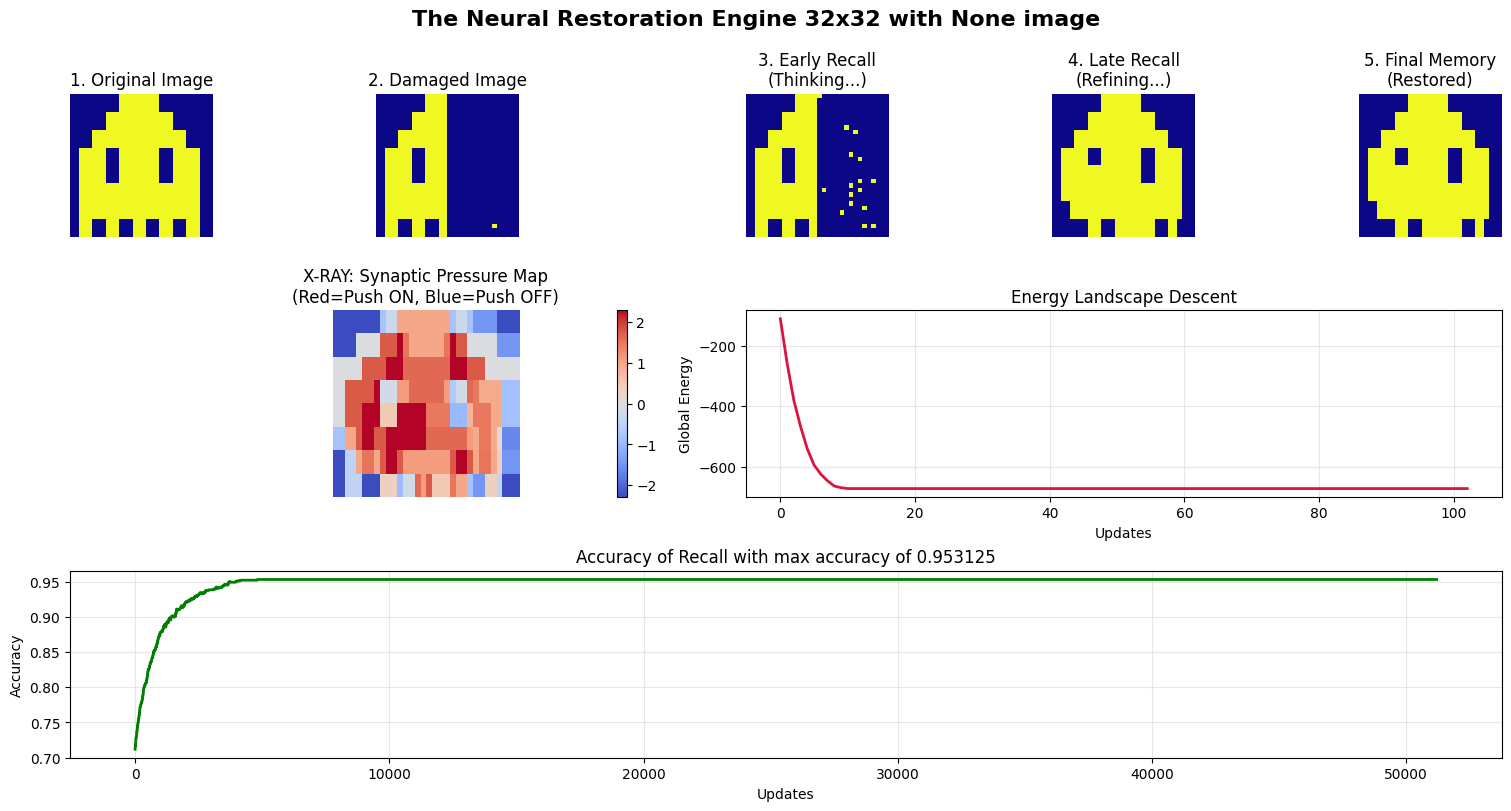

In [355]:
result = attempt_restore_memory(selected_arts, "Ghost", names=names)
plot_restoration(result)

### Let's test with random images

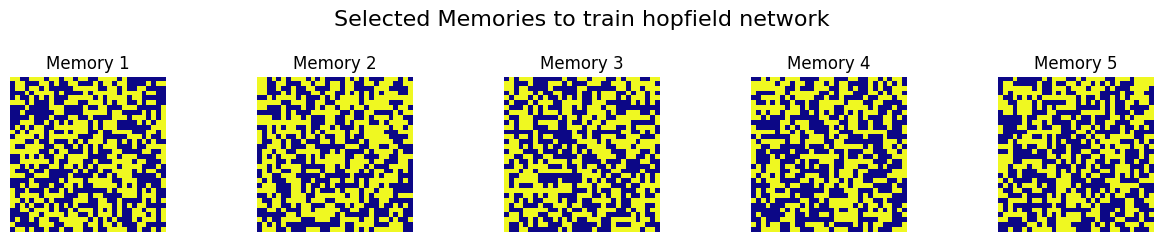

In [356]:
random_patterns = art.get_random_binary_images(SIZE, 5)
plot_selected_arts(random_patterns)

Learning 5 memories with 1024 neurons...
Synaptic Connections: 1,048,576 weights.
Dreaming restoration...


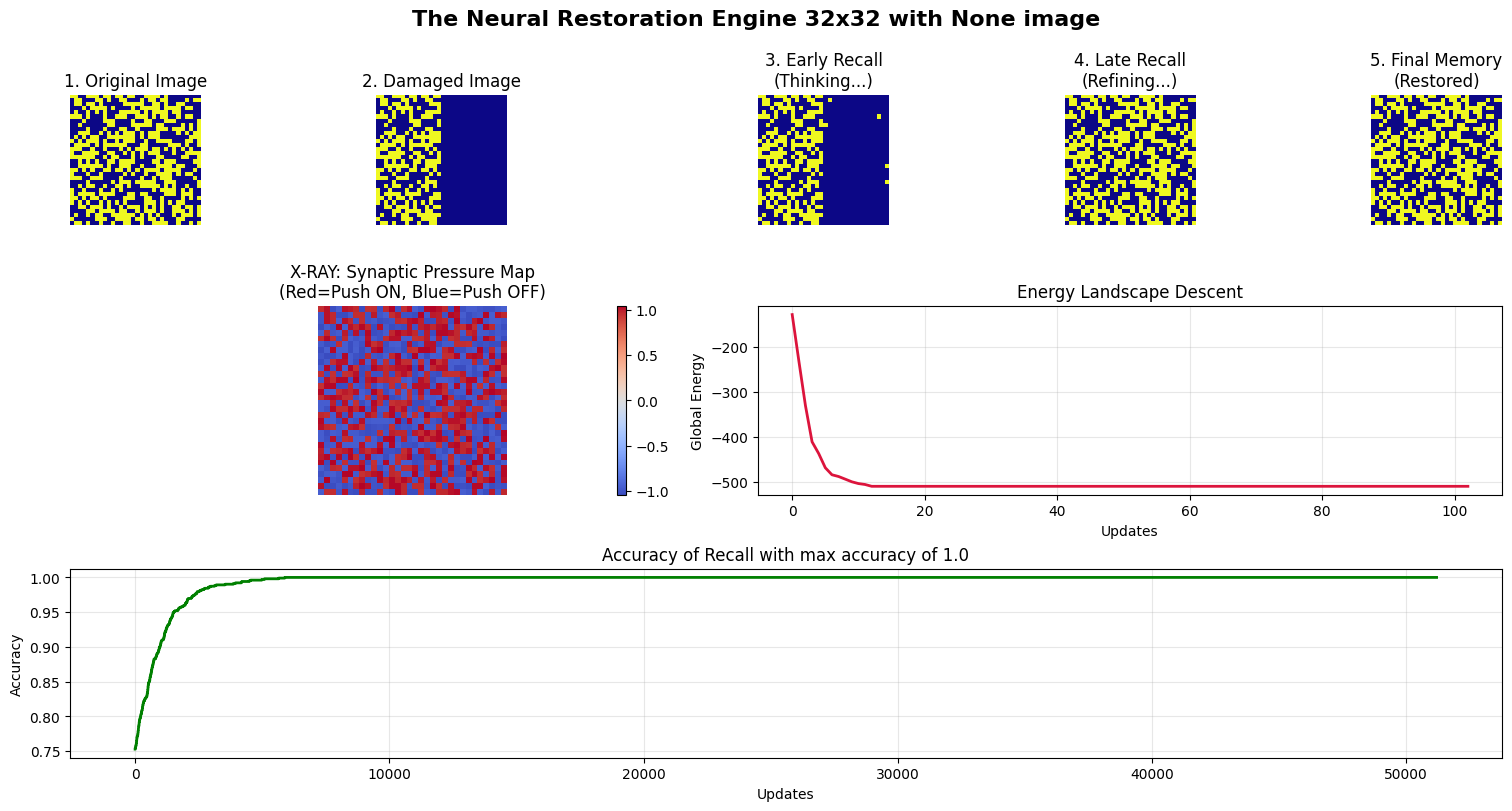

In [357]:
net = HopfieldNetwork(SIZE)
net.train(random_patterns)
result = attempt_restore_memory(random_patterns, 0)
plot_restoration(result)